In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

# RESULTS = Path('../results')
RESULTS = Path('../results/NEW_DATA')
DETECTORS = ['mahal', 'gmm', 'ocsvm', 'iforest']
DOMAINS   = ['synthetic', 'lightbox', 'sunlamp']
DETECTOR_LABELS = {'mahal': 'Mahalanobis', 'gmm': 'GMM', 'ocsvm': 'One-Class SVM', 'iforest': 'Isolation Forest'}

# match the palette / style used in plot_mahal_scores
DOMAIN_COLORS = {'synthetic': '#2166ac', 'lightbox': '#4f0942', 'sunlamp': '#d6604d'}
DOMAIN_LABELS = {'synthetic': 'Synthetic', 'lightbox': 'Lightbox HIL', 'sunlamp': 'Sunlamp HIL'}

plt.rcdefaults()
plt.rcParams.update({
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'legend.frameon':    False,
    'figure.dpi':        150,
})

# look at the two pose-error components separately, not the blended SPEED score
COMPONENTS = {'E_R': 'Rotation Error  [deg]', 'E_T': 'Translation Error  [m]'}

def signed_log(scores):
    # from calibration.py
    return np.sign(scores) * np.log1p(np.abs(scores))

def load(detector, domain):
    scores = np.load(RESULTS / f'anomaly_scores_{detector}_{domain}.npy')
    df = pd.read_csv(RESULTS / f'per_image_errors_{domain}.csv')
    n = min(len(scores), len(df))
    errors = {comp: df[comp].values[:n] for comp in COMPONENTS}
    return signed_log(scores[:n]), errors

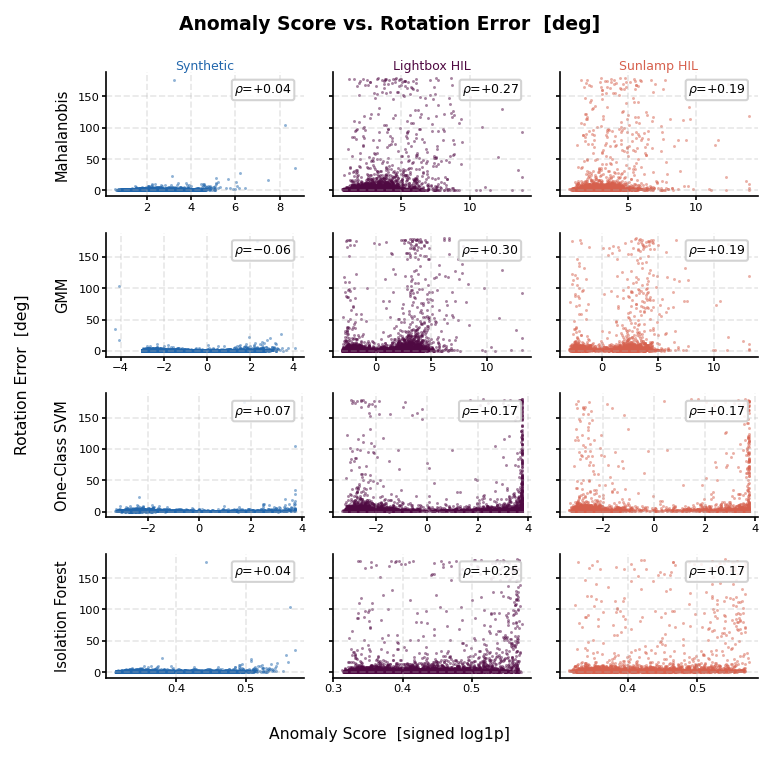

Saved → figures/score_E_R_correlation.(pdf|png)


In [2]:
# Compact (n_detectors x 3) grid for one error component — rows = detector, cols = domain.
# Domain is the column header, detector the row header; one shared axis label per side.
def plot_score_correlation(comp):
    comp_label = COMPONENTS[comp]
    nrows = len(DETECTORS)
    fig, axes = plt.subplots(nrows, 3, figsize=(5.2, 1.25 * nrows),
                             sharex=False, sharey=True)
    fig.suptitle(f'Anomaly Score vs. {comp_label}', fontsize=9, fontweight='bold')

    for row, det in enumerate(DETECTORS):
        for col, dom in enumerate(DOMAINS):
            ax = axes[row, col]
            scores, errors = load(det, dom)
            err = errors[comp]
            rho, pval = spearmanr(scores, err)

            ax.scatter(scores, err, s=2, alpha=0.5, color=DOMAIN_COLORS[dom],
                       linewidths=0, rasterized=True)

            sign = '+' if rho >= 0 else '−'
            ax.text(0.94, 0.92, f'$\\rho$={sign}{abs(rho):.2f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=6,
                    bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='0.8', alpha=0.85))

            if row == 0:                       # domain column header
                ax.set_title(DOMAIN_LABELS[dom], color=DOMAIN_COLORS[dom],
                             fontsize=6, pad=1)
            if col == 0:                       # detector row header
                ax.set_ylabel(DETECTOR_LABELS[det], fontsize=7)
            ax.tick_params(labelsize=5.5, length=2, pad=1)

    # single shared axis labels instead of repeating on every panel
    fig.supxlabel('Anomaly Score  [signed log1p]', fontsize=7.5)
    fig.supylabel(comp_label, fontsize=7.5)

    fig.tight_layout()
    out = f'../figures/score_{comp}_correlation'
    fig.savefig(out + '.pdf', bbox_inches='tight')
    fig.savefig(out + '.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/score_{comp}_correlation.(pdf|png)')


# Rotation error
plot_score_correlation('E_R')

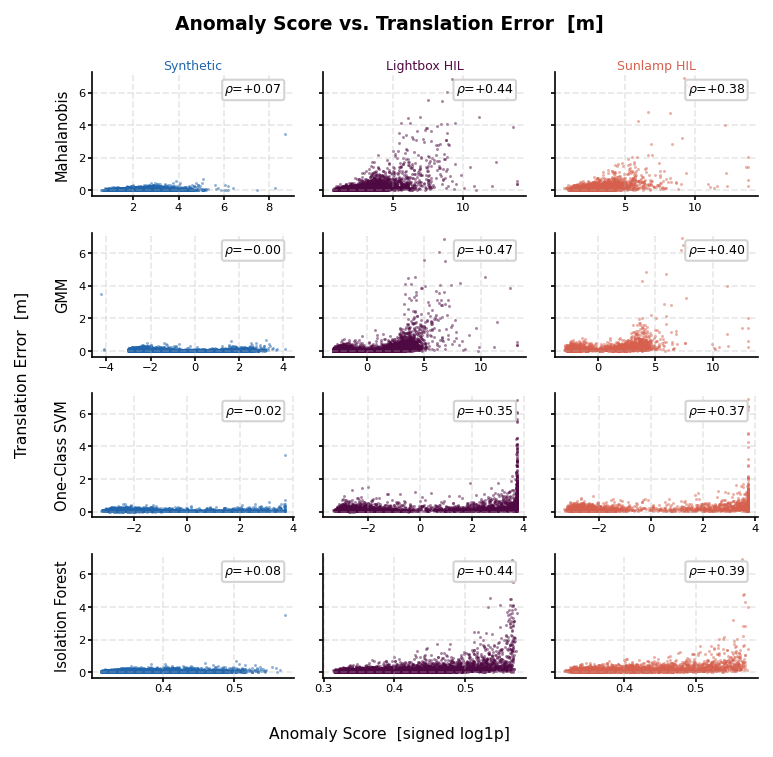

Saved → figures/score_E_T_correlation.(pdf|png)


In [3]:
# Translation error
plot_score_correlation('E_T')
